# =============================================================================
# Jupyter Notebook about cluster methodology
# Aplication to Weather Regimes
# =============================================================================


## Tomamos los datos del ERA5 en MAM diariamente ( años multiplicados por 92 días)


In [1]:
import pandas as pd

from werim import Dataset, Clim, Anom, Region, Month

In [7]:
ds = Dataset("slp_daily_1940_2024_era5data1g.nc", folder="ejemplos").open()
ds.slice(Region(
    lat0=20, latf=64, lon0=-40, lonf=39,
    month0=Month.MAR, monthf=Month.MAY,
    year0=1940, yearf=2024,
))

INFO 2026-06-18 15:23:13: Detected variable msl from: msl


((<Figure size 1422.22x800 with 2 Axes>,), (<GeoAxes: >,))

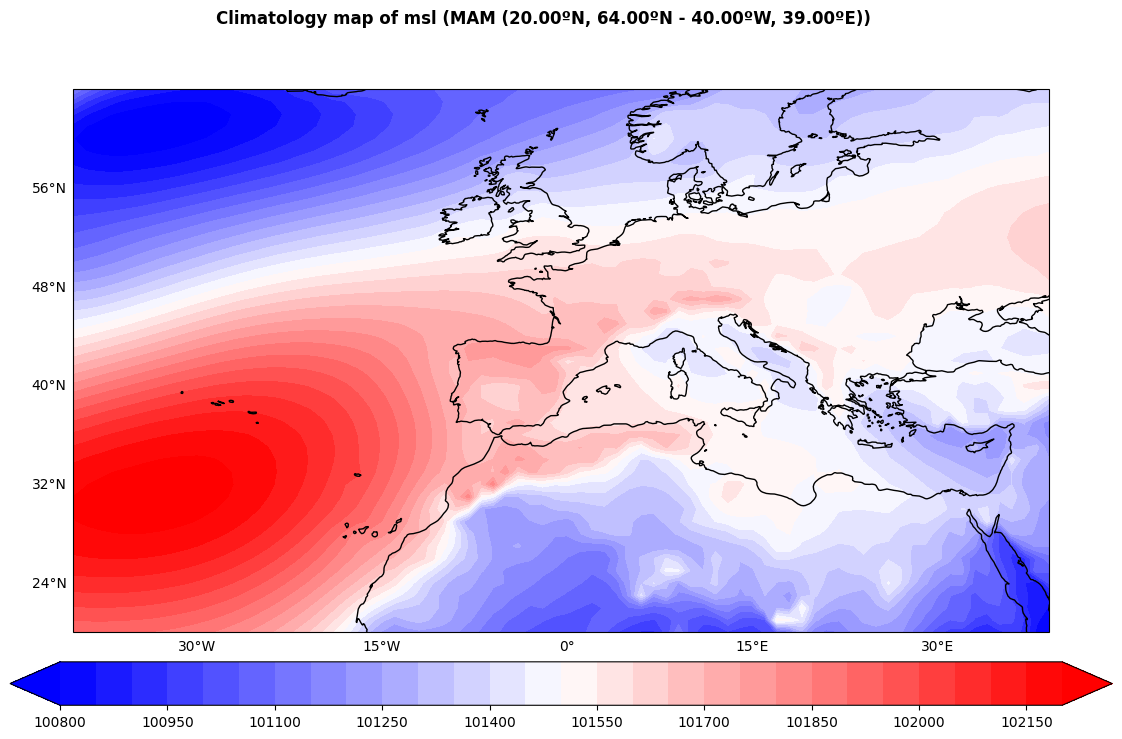

In [9]:
Clim(ds, "map").plot(cmap="bwr", levels=30)

In [11]:
anom.time

<xarray.DataArray 'time' (time: 7820)> Size: 63kB
array(['1940-03-01T00:00:00.000000000', '1940-03-02T00:00:00.000000000',
       '1940-03-03T00:00:00.000000000', ...,
       '2024-05-29T00:00:00.000000000', '2024-05-30T00:00:00.000000000',
       '2024-05-31T00:00:00.000000000'],
      shape=(7820,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 63kB 1940-03-01 1940-03-02 ... 2024-05-31
    year     (time) int64 63kB 1940 1940 1940 1940 1940 ... 2024 2024 2024 2024
Attributes:
    standard_name:  time
    axis:           T

((<Figure size 1422.22x800 with 2 Axes>,), (<GeoAxes: >,))

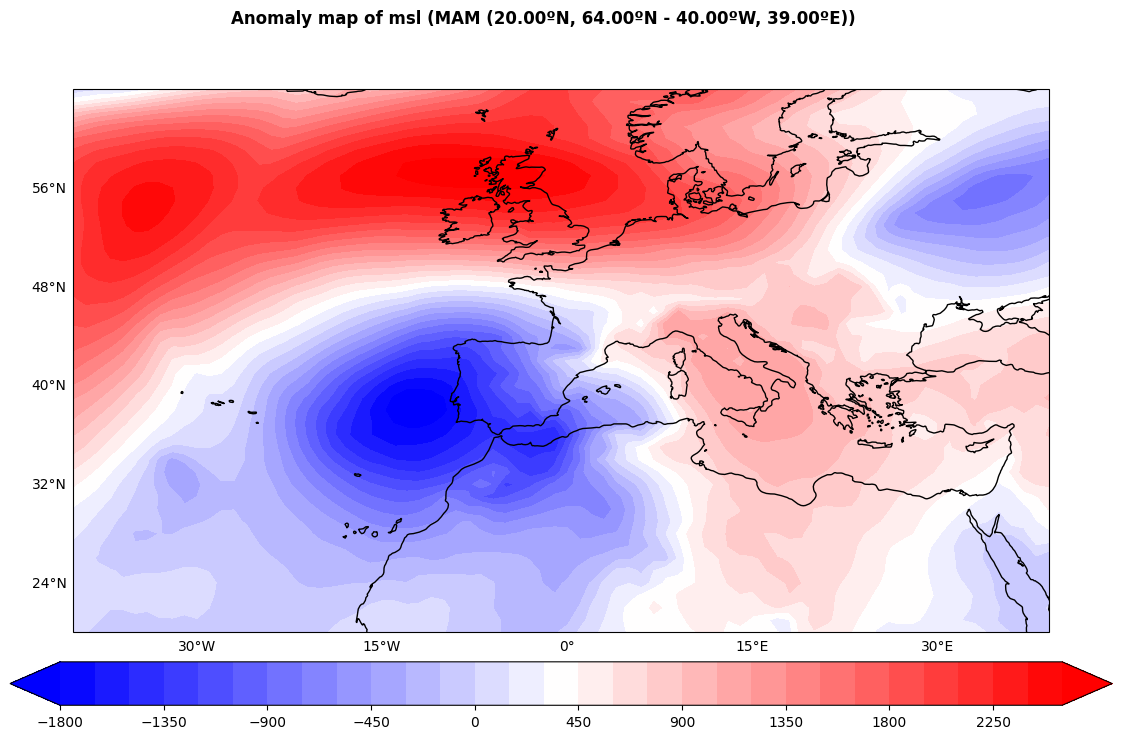

In [12]:
anom = Anom(ds, "map", group_season=False)
anom.plot(timestamp="1940-03-01", cmap="bwr", levels=30)

Finally, we reshape for having all times together

In [13]:
anom.data.shape #años,dias, lat,lon

(7820, 45, 80)

=============================================================================
# ANALISIS EOF
# =============================================================================
 Ahora vamos a calcular los principales modos de variabilidad del z600 anómalo. Para ello, primero eliminamos la tendencia y aplicamos la función EOF, definida anteriormente. La función tiene que ser aplicada a datos con dimensiones (ns, nt), así que transponemos, y reformamos para tener 2 dimensiones# 

In [14]:
anom_MAM_ns = signal.detrend(slp_MAMa, axis=0, type='linear')
#Mata=anom_MAM_ns.reshape(7820, 45* 80) # Pasamos los datos a ns*nt
Mata=anom_MAM_ns.reshape(7268, 45* 80)

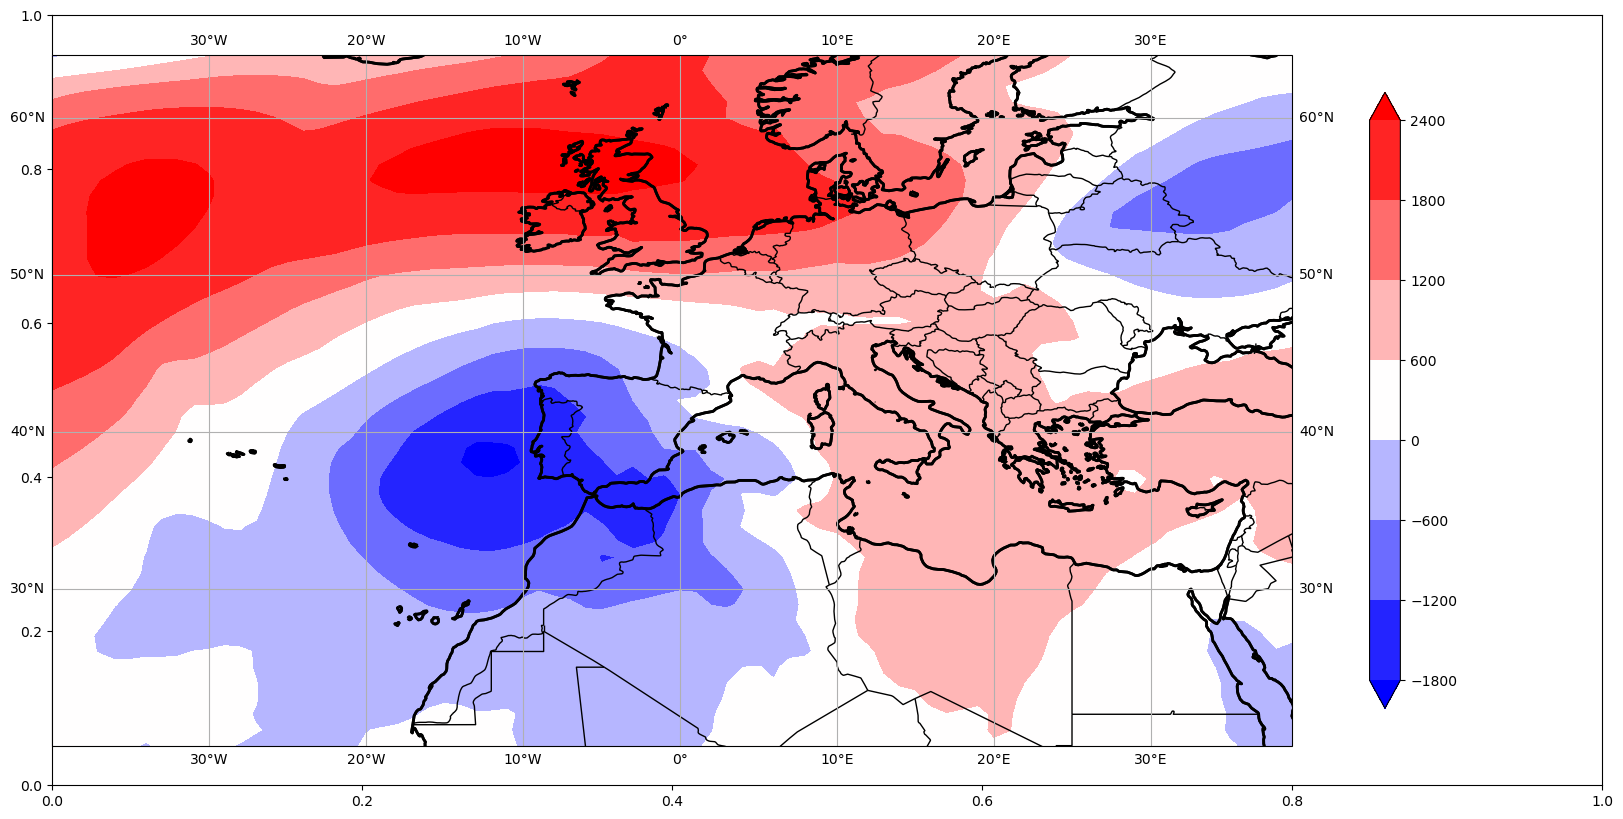

In [15]:
#pinta anomMAM_ns para ver si está bien
fig, ax = plt.subplots(figsize=(20, 10))
ax=plt.subplot(projection=ccrs.PlateCarree(0))
ax.coastlines(linewidth = 2)
ax.add_feature(cartopy.feature.BORDERS, linewidth = 1)
#ax.set_extent([np.min(LW), np.max(LE), np.min(LS), np.max(LN)], ccrs.PlateCarree())
im = ax.contourf(z.lon,z.lat,anom_MAM_ns[0,:,:],cmap='bwr',extend='both',
                transform = ccrs.PlateCarree(0))
fig.colorbar(im,ax=ax,orientation = 'vertical',shrink=0.8, label = '')
    
#colocamos las labels y el título
gl=ax.gridlines(draw_labels = True,zorder = 0); #grid
gl.ylabels_right = False #label y axis in rigth size
gl.xlabels_top = False #label x axis in top
title = ''
ax.set_title(title)
ax.coastlines(linewidth = 2)

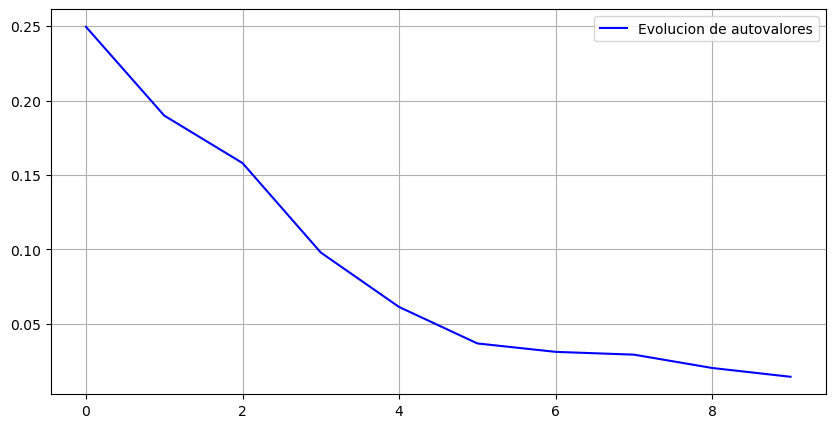

In [16]:
C=np.dot(np.transpose(Mata),Mata) #ns,ns
eof,d,eof2=linalg.svd(C)
fvar=(d)/sum(d)
fig,ax = plt.subplots(figsize = (10,5))
plt.plot(fvar[:10],color='Blue',label='Evolucion de autovalores')
plt.legend()
plt.grid()

In [17]:
PC=np.dot(Mata,eof[:,:10]) #cojo 10 autovectores 
PCs=(PC-np.mean(PC))/np.std(PC) #PCs[:,1:10]
PCs.shape

(7268, 10)

In [18]:
#¿cuánto explican las 3 primeras?
np.sum(fvar[:3])

np.float32(0.5975551)

In [19]:
PCs.shape

(7268, 10)

In [22]:
#voy a pintar la primera usando index regression
cor1,Pvalue1,cor_sig1,reg1,reg1_sig=IndexRegrCorr(np.transpose(Mata),np.transpose(PCs[:,0]),0.01,'MonteCarlo',100)
cor2,Pvalue2,cor_sig2,reg2,reg2_sig=IndexRegrCorr(np.transpose(Mata),np.transpose(PCs[:,1]),0.01,'MonteCarlo',100)
cor3,Pvalue3,cor_sig3,reg3,reg3_sig=IndexRegrCorr(np.transpose(Mata),np.transpose(PCs[:,2]),0.01,'MonteCarlo',100)

In [20]:
nm=10
REG=np.zeros([nm,ns]) #guardo las 10 PCs en las que proyecto los dias y los clusters
for i in range(nm):
    corx,Pvaluex,cor_sigx,regx,regx_sig=IndexRegrCorr(np.transpose(Mata),np.transpose(PCs[:,i]),0.01,'MonteCarlo',100)
    REG[i,:]=regx

In [21]:
#REG.shape  en realidad no necesito 10 pero podría hacerlos

(10, 3600)

Text(0.5, 1.0, 'First Principal Component MAM fvar=0.25')

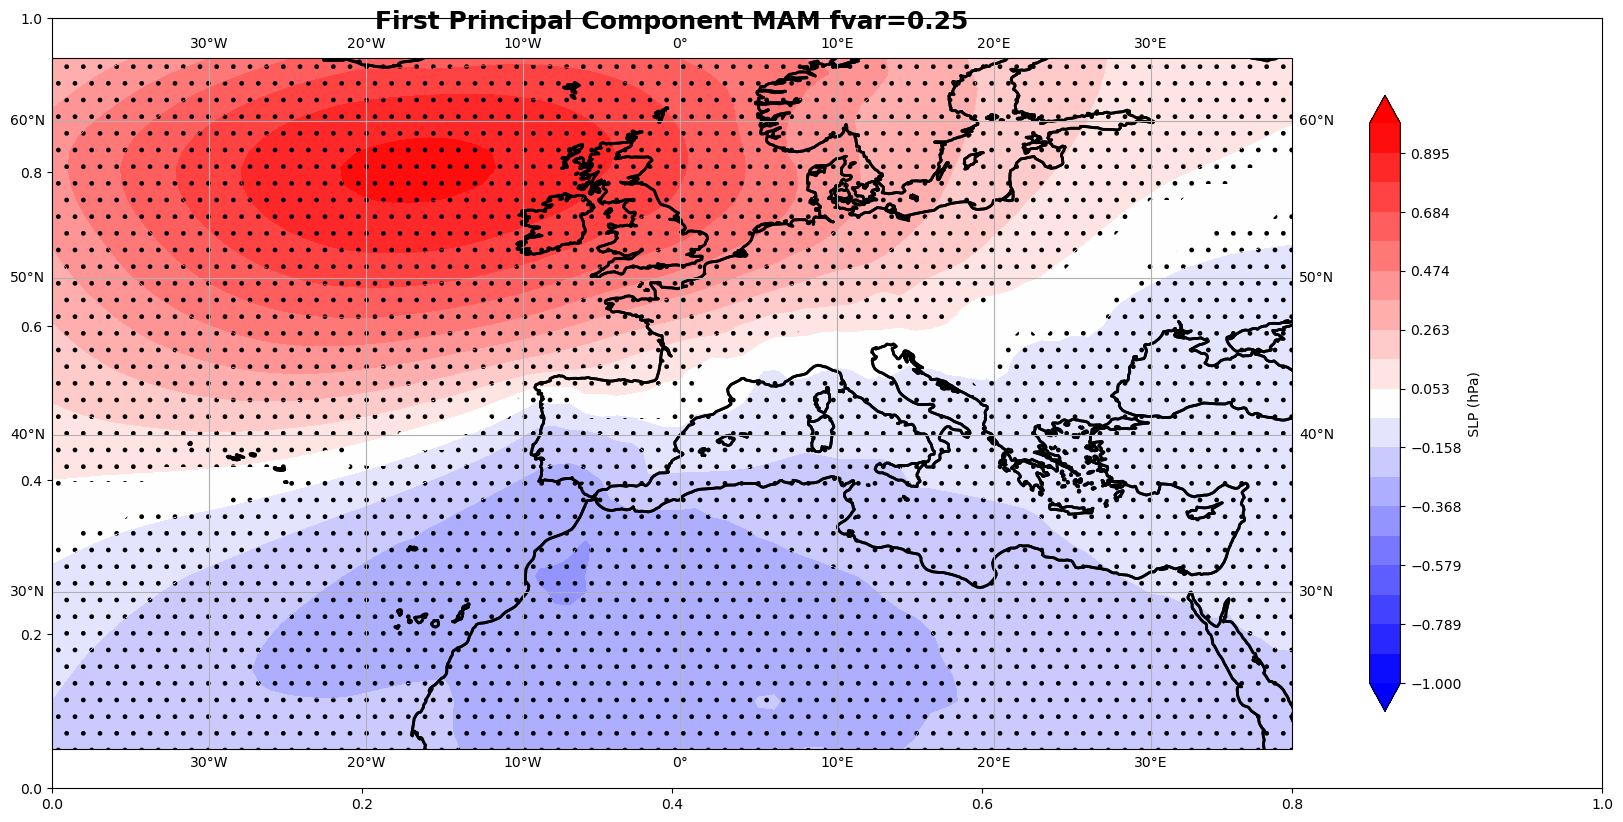

In [24]:
#pinto las primeras EOFs 
fig, ax = plt.subplots(figsize=(20, 10), ncols=1)
ax=plt.subplot(1,1,1,projection=ccrs.PlateCarree())
ax.coastlines(linewidth = 2)
im = ax.contourf(z.lon,z.lat,cor1.reshape(nlat,nlon),
                 cmap='bwr',levels=np.linspace(-1,1,20),extend='both', transform = ccrs.PlateCarree())
ax.coastlines(linewidth = 2)
ax.contourf(z.lon,z.lat,cor_sig1.reshape(nlat,nlon),
                 cmap='bwr',hatches='.',levels=np.linspace(-1,1,20),extend='both', transform = ccrs.PlateCarree())
ax.coastlines()
fig.colorbar(im,ax=ax,orientation = 'vertical',shrink=0.8, label = ' SLP (hPa) ')
gl=ax.gridlines(draw_labels = True); #grid
gl.ylabels_right = False #label y axis in rigth size
gl.xlabels_top = False #label x axis in top   
ax.grid()
ax.set_title('First Principal Component MAM fvar={}'.format(str(np.round(fvar[0],2))),fontsize=18,weight='bold')


/home/irene/miniconda3/envs/cao_tropa3/lib/python3.9/site-packages/cartopy/mpl/gridliner.py:487: UserWarning: The .ylabels_right attribute is deprecated. Please use .right_labels to toggle visibility instead.
  warnings.warn('The .ylabels_right attribute is deprecated. Please '
/home/irene/miniconda3/envs/cao_tropa3/lib/python3.9/site-packages/cartopy/mpl/gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '


Text(0.5, 1.0, 'Second Principal Component MAM fvar=0.19')

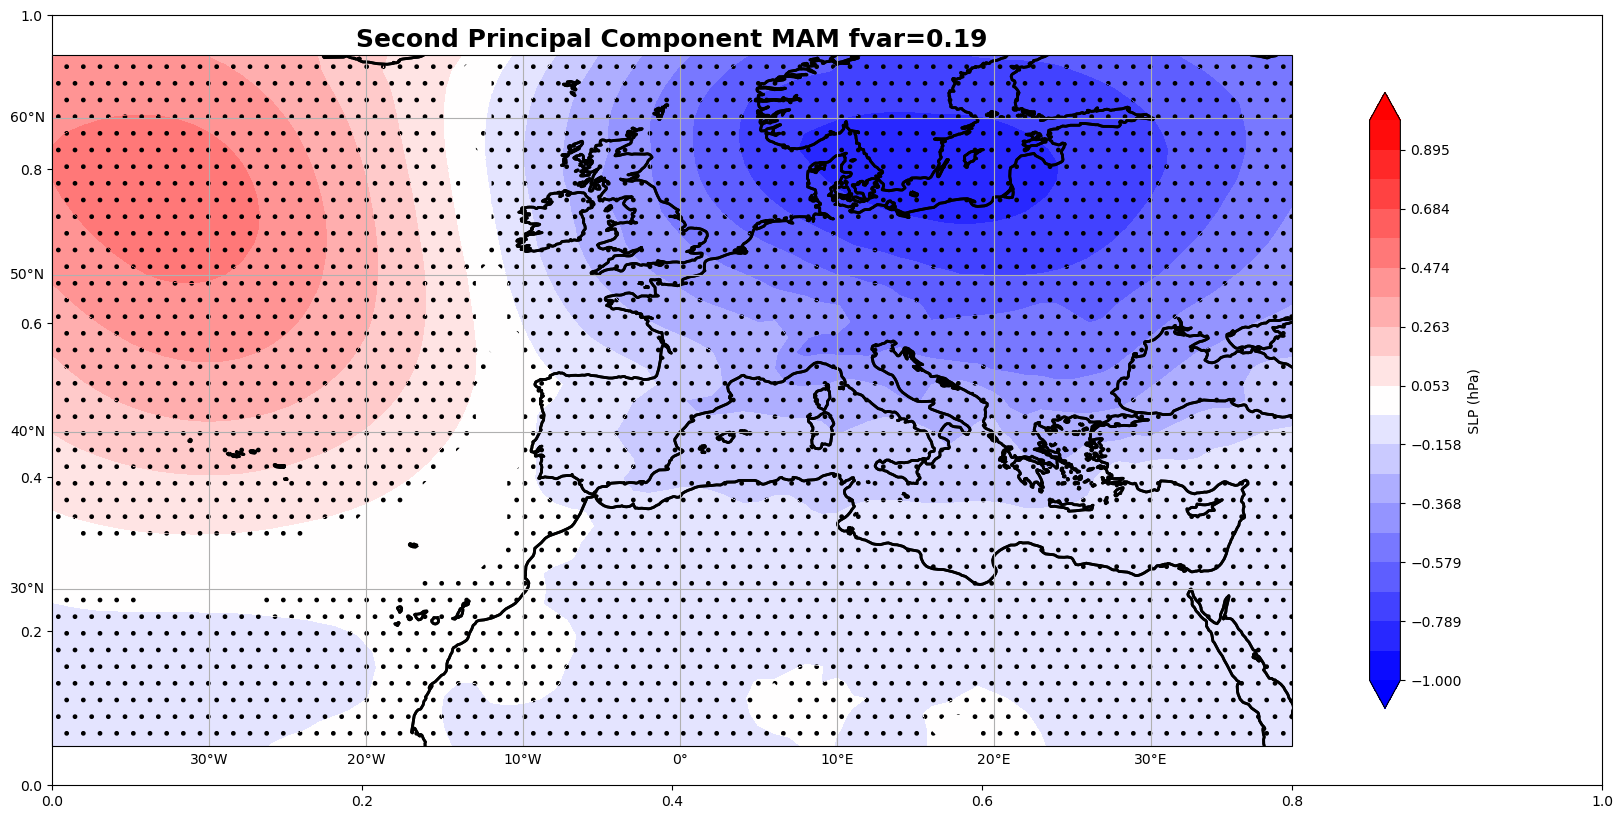

In [187]:
#pinto las primeras EOFs 
fig, ax = plt.subplots(figsize=(20, 10), ncols=1)
ax=plt.subplot(1,1,1,projection=ccrs.PlateCarree())
ax.coastlines(linewidth = 2)
im = ax.contourf(z.lon,z.lat,cor2.reshape(nlat,nlon),
                 cmap='bwr',levels=np.linspace(-1,1,20),extend='both', transform = ccrs.PlateCarree())
ax.coastlines(linewidth = 2)
ax.contourf(z.lon,z.lat,cor_sig2.reshape(nlat,nlon),
                 cmap='bwr',hatches='.',levels=np.linspace(-1,1,20),extend='both', transform = ccrs.PlateCarree())
ax.coastlines()
fig.colorbar(im,ax=ax,orientation = 'vertical',shrink=0.8, label = ' SLP (hPa) ')
gl=ax.gridlines(draw_labels = True); #grid
gl.ylabels_right = False #label y axis in rigth size
gl.xlabels_top = False #label x axis in top   
ax.set_title('Second Principal Component MAM fvar={}'.format(str(np.round(fvar[1],2))),fontsize=18,weight='bold')

/home/irene/miniconda3/envs/cao_tropa3/lib/python3.9/site-packages/cartopy/mpl/gridliner.py:487: UserWarning: The .ylabels_right attribute is deprecated. Please use .right_labels to toggle visibility instead.
  warnings.warn('The .ylabels_right attribute is deprecated. Please '
/home/irene/miniconda3/envs/cao_tropa3/lib/python3.9/site-packages/cartopy/mpl/gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '


Text(0.5, 1.0, 'Third Principal Component MAM fvar=0.16')

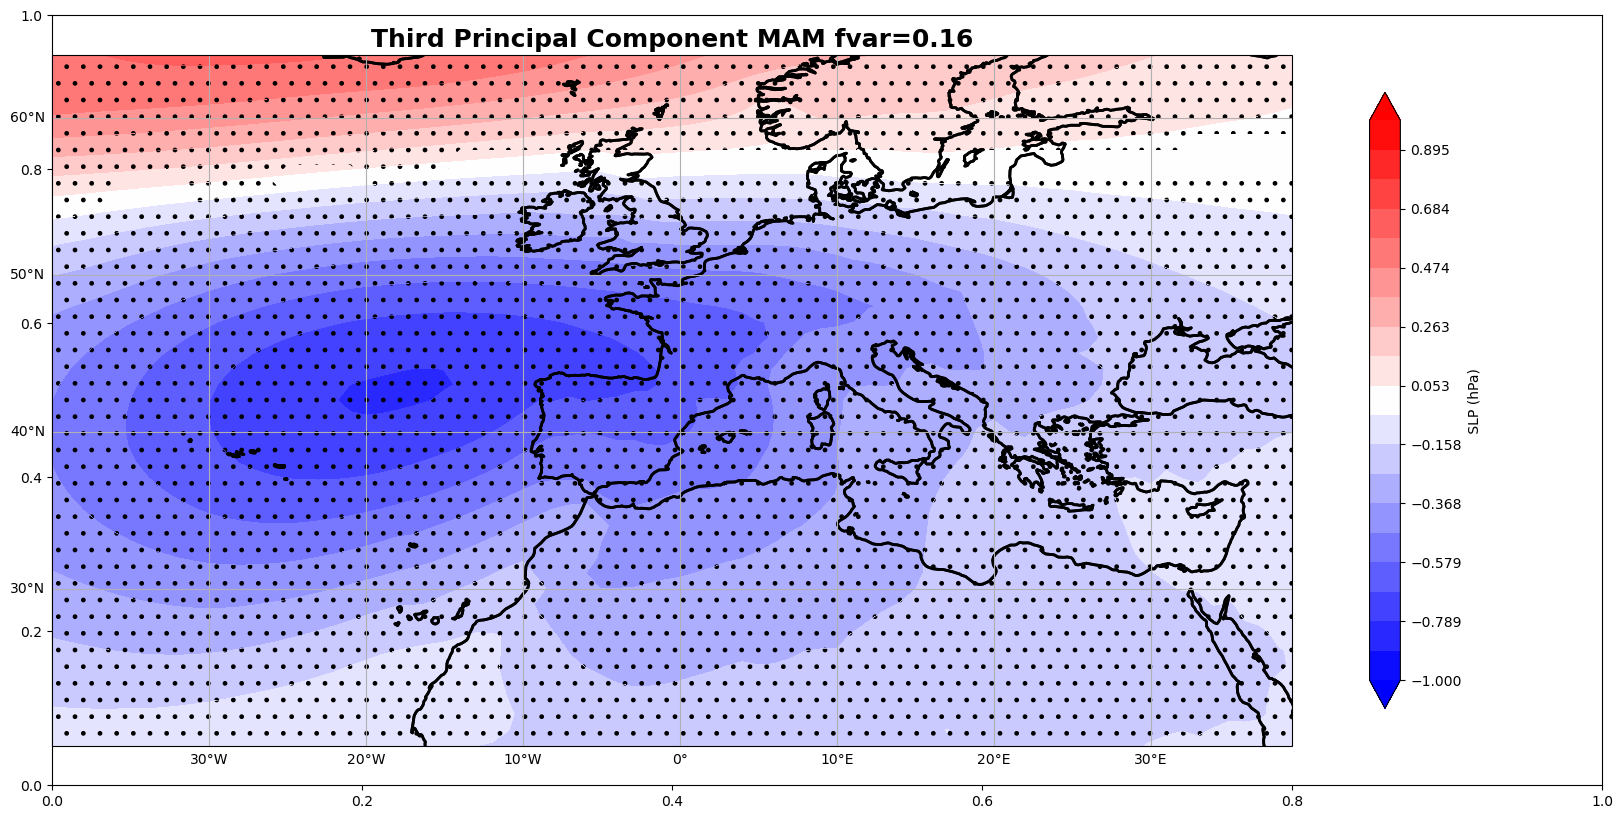

In [188]:
#pinto las primeras EOFs 
fig, ax = plt.subplots(figsize=(20, 10), ncols=1)
ax=plt.subplot(1,1,1,projection=ccrs.PlateCarree())
ax.coastlines(linewidth = 2)
im = ax.contourf(z.lon,z.lat,cor3.reshape(nlat,nlon),
                 cmap='bwr',levels=np.linspace(-1,1,20),extend='both', transform = ccrs.PlateCarree())
ax.coastlines(linewidth = 2)
ax.contourf(z.lon,z.lat,cor_sig3.reshape(nlat,nlon),
                 cmap='bwr',hatches='.',levels=np.linspace(-1,1,20),extend='both', transform = ccrs.PlateCarree())
ax.coastlines()
fig.colorbar(im,ax=ax,orientation = 'vertical',shrink=0.8, label = ' SLP (hPa) ')
gl=ax.gridlines(draw_labels = True); #grid
gl.ylabels_right = False #label y axis in rigth size
gl.xlabels_top = False #label x axis in top   
ax.set_title('Third Principal Component MAM fvar={}'.format(str(np.round(fvar[2],2))),fontsize=18,weight='bold')




# =============================================================================
# DIBUJAR (3 primeros modos PCs )
# =============================================================================



/tmp/ipykernel_3618531/529045786.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(np.arange(1979,2021))


Text(0.5, 1.0, 'Third PC MAM fvar=0.16')

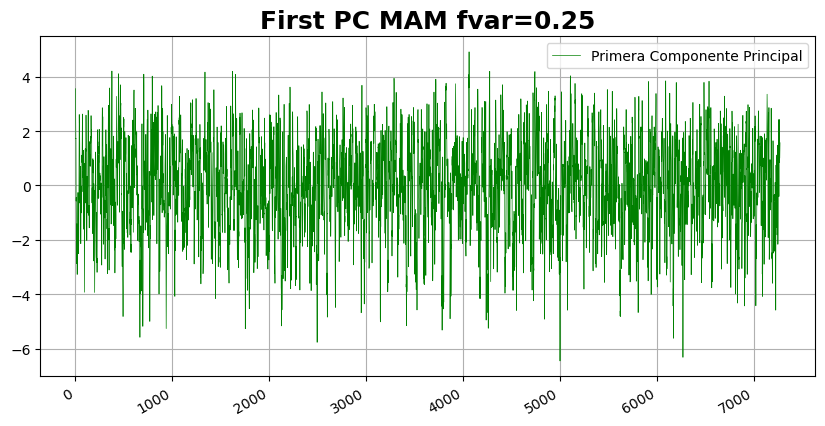

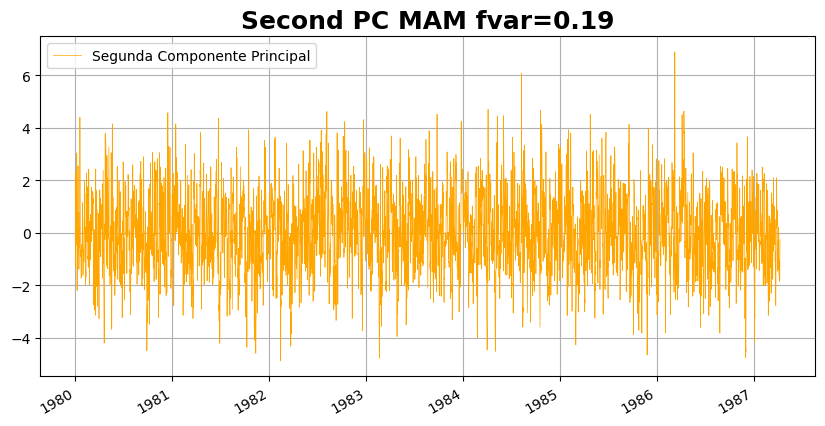

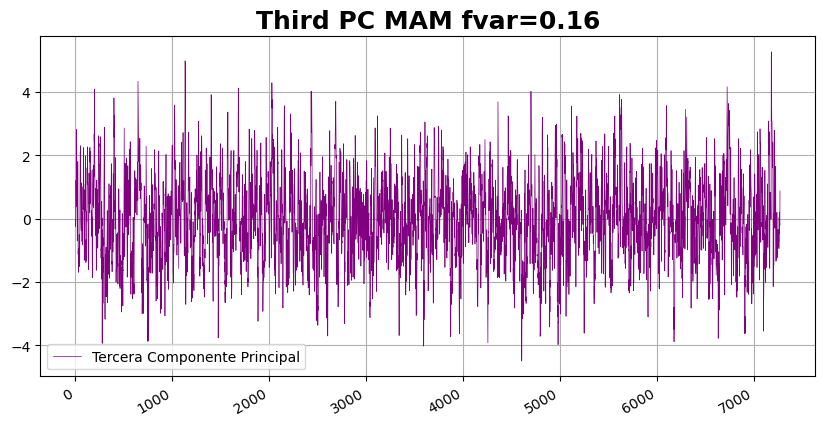

In [25]:
season='MAM'

# First PC
fig,ax=plt.subplots(figsize = (10,5))
fig.autofmt_xdate(rotation=30) #para rotar las fechas en la etiqueta
ax.plot(PCs[:,0],linewidth= 0.5,color='green',label='Primera Componente Principal')
 
#ax.set_xticklabels(np.arange(1979,2021))

ax.grid()
ax.legend()
ax.set_title('First PC ' + season + ' fvar={}'.format(str(np.round(fvar[0],2))),fontsize=18,weight='bold')


# Second PC
fig,ax=plt.subplots(figsize = (10,5))
fig.autofmt_xdate(rotation=30) #para rotar las fechas en la etiqueta
ax.plot(PCs[:,1],linewidth= 0.5,color='orange',label='Segunda Componente Principal')
ax.set_xticklabels(np.arange(1979,2021))


#ax.set_xticklabels(np.arange(2020,2050))
ax.grid()
ax.legend()
ax.set_title('Second PC ' + season + ' fvar={}'.format(str(np.round(fvar[1],2))),fontsize=18,weight='bold')




# Third PC
fig,ax=plt.subplots(figsize = (10,5))
fig.autofmt_xdate(rotation=30) #para rotar las fechas en la etiqueta
ax.plot(PCs[:,2],linewidth= 0.5,color='purple',label='Tercera Componente Principal')
#ax.set_xticklabels(np.arange(1979,2021))


ax.grid()
ax.legend()
ax.set_title('Third PC ' + season + ' fvar={}'.format(str(np.round(fvar[2],2))),fontsize=18,weight='bold')





/tmp/ipykernel_3618531/1155975395.py:4: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter3D(PCs[:,0],PCs[:,1],PCs[:,2], cmap='Greens', alpha=0.1, s=1.5)


Text(0.5, 0.92, 'Scatter Plot PCs')

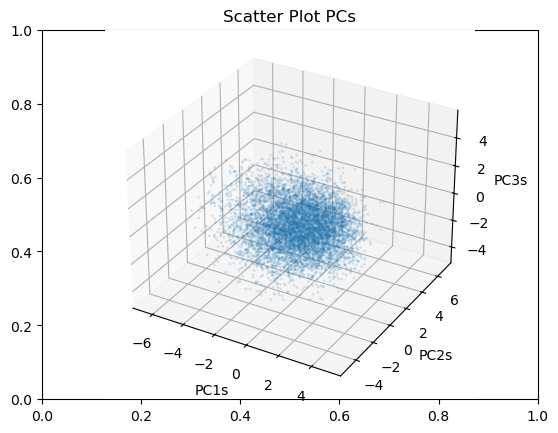

In [26]:

### Plot the first 3 PCS so you can see 
fig,ax = plt.subplots()
ax = plt.subplot(1,1,1, projection='3d')
ax.scatter3D(PCs[:,0],PCs[:,1],PCs[:,2], cmap='Greens', alpha=0.1, s=1.5)
ax.set_xlabel('PC1s')
ax.set_ylabel('PC2s')
ax.set_zlabel('PC3s')
ax.grid()
ax.set_title('Scatter Plot PCs')




In [191]:
PCs.shape

(7820, 10)

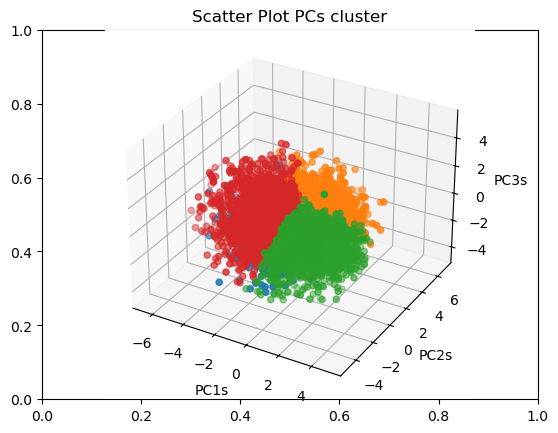

In [27]:
k=4
# For example, we decide that 5...
centroides, index = cluster.vq.kmeans2((PCs ),k)

#ahora representamos las PCs con los centroides
fig,ax = plt.subplots()
ax = plt.subplot(1,1,1, projection='3d')
ax.set_xlabel('PC1s')
ax.set_ylabel('PC2s')
ax.set_zlabel('PC3s')
ax.grid()
ax.set_title('Scatter Plot PCs cluster')

for nk in range(k):  
    ax.scatter3D(PCs[index==nk,0],PCs [index==nk,1],PCs [index==nk,2])

In [ ]:
 LO SIGUIENTE SERIA SI QUIERO HACER EL INFORMATION CRITERIA

# =============================================================================
# WEATHER REGIMES (REGÍMENES DE TIEMPO)




### Elijo un número máximo de cluster, por ejemplo, 10 y un umbral de temperatura o un percentil( por ejemplo, p95). 
### La idea es ver cuantos clusters necesito para explicar ese extremo . 
### Además, elijo un número de iteraciones para repetir el proceso y ver si es robusto. 



# Aqui tenéis que adaptar para que, de vuestro índice, tome un umbral y asi selecciones cuántos clusters hacen falta para poder diferenciar un cluster que lo contenga

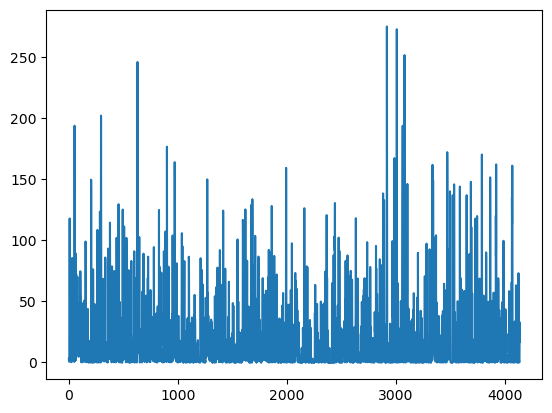

In [192]:
path2='/home/irene/'
pt=xr.open_dataset(path2 +'Spain02_v5.0_DD_010reg_aa3d_pr.nc')
pteste=pt.sel(lat=slice(36.2,43),lon=slice(-2,4))
lonpr=pt.lon; latpr=pt.lat; preci=pteste.pr
preciMAM=preci.groupby('time.season')['MAM']
preciMAMday=np.mean(np.mean(preciMAM,2),1) #este es el indice diario desde 1971 hasta 215
plt.plot(preciMAMday)

In [ ]:
preciMAMday.shape #45 años x 92

(4140,)

(array([3.364e+03, 4.750e+02, 1.520e+02, 7.600e+01, 4.000e+01, 2.200e+01,
        4.000e+00, 3.000e+00, 1.000e+00, 3.000e+00]),
 array([  0.        ,  27.49381065,  54.98762131,  82.48143005,
        109.97524261, 137.46905518, 164.96286011, 192.4566803 ,
        219.95048523, 247.44430542, 274.93811035]),
 <BarContainer object of 10 artists>)

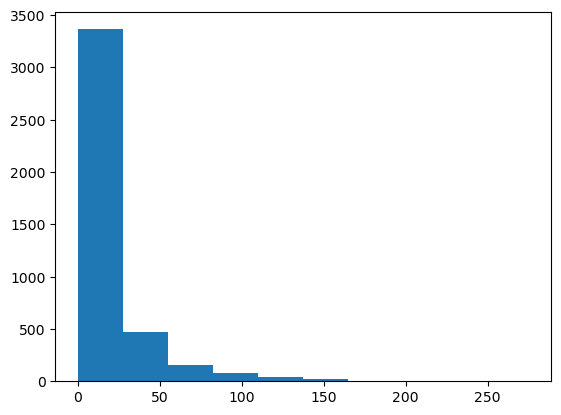

In [234]:
plt.hist(indiceExtremo)

/home/meteo_prof/.conda/envs/analisis1/lib/python3.10/site-packages/scipy/cluster/vq.py:607: UserWarning: One of the clusters is empty. Re-run kmeans with a different initialization.
  warnings.warn("One of the clusters is empty. "


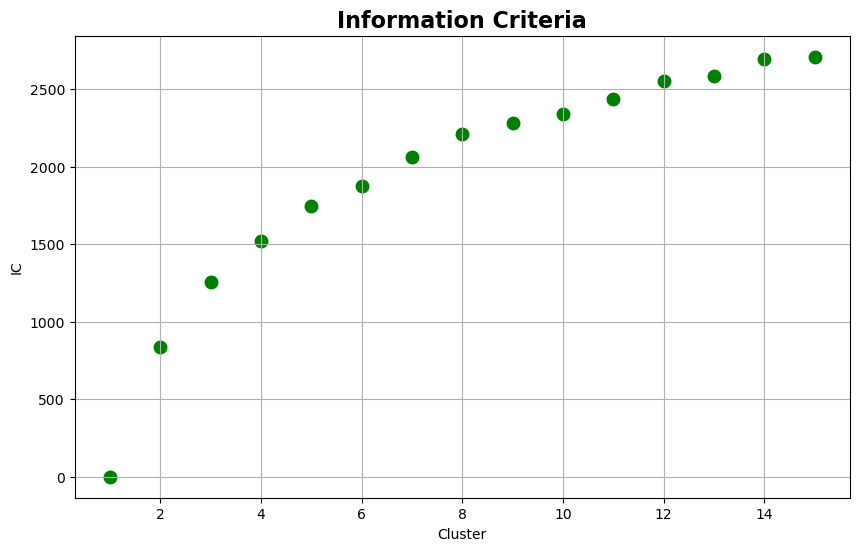

In [ ]:
indiceExtremo=preciMAMday #desde 1971 hasta 2015 45 años
yearslp=np.arange(1940,2025)
iyslp=(yearslp >1970) & (yearslp <2016) #los años que solapan con Extremo


PCs_periodExt=PCs[inslp]  #period for the extreme index 1971_2015 
wtmax = 15; #maximum number of cluster
p95 = np.percentile(indiceExtremo, 95)
thr =p95;
itermax =40;
# Now we fix the number of iterations that we are going to use
#for calculating the probability of rainfall higher than the threshold 
ndd = indiceExtremo[indiceExtremo < thr].size; # to do that, we count the
# number of days with rainfall lower than a threshold
prob = ndd / indiceExtremo.size; # dividing ndd by the total number of days
# we have the probability

#we calculate the information criteria following the paper of Morón et al
IC=ma.empty([itermax,wtmax])
for it in range(itermax): # we test with different iterations
    for Nwt in range(wtmax): # we test with different number of clusters
        IC[it,Nwt]=0
        for k in range(Nwt):
            centroides,indexic = cluster.vq.kmeans2(PCs_periodExt, k+1)      
            # we calculate the IC
            nk = np.array(np.where(indexic==k)).shape[1] # number of days with cluster k
            ndk = np.array(np.where((indexic== k) & (indiceExtremo> thr))).shape[1];
            IC[it,Nwt] =  IC[it,Nwt] + abs(ndk - prob * nk); #contribution to the  IC
            
IC.mean(axis=1).shape

fig,ax = plt.subplots(1,1,figsize=(10,6))
ax.set_title('Information Criteria',fontsize=16,weight='bold')
ax.set_xlabel('Cluster')
ax.set_ylabel('IC')
ax.scatter(range(1,wtmax+1),np.nanmean(np.array(IC),0),linewidth= 4,color='green')
ax.grid()



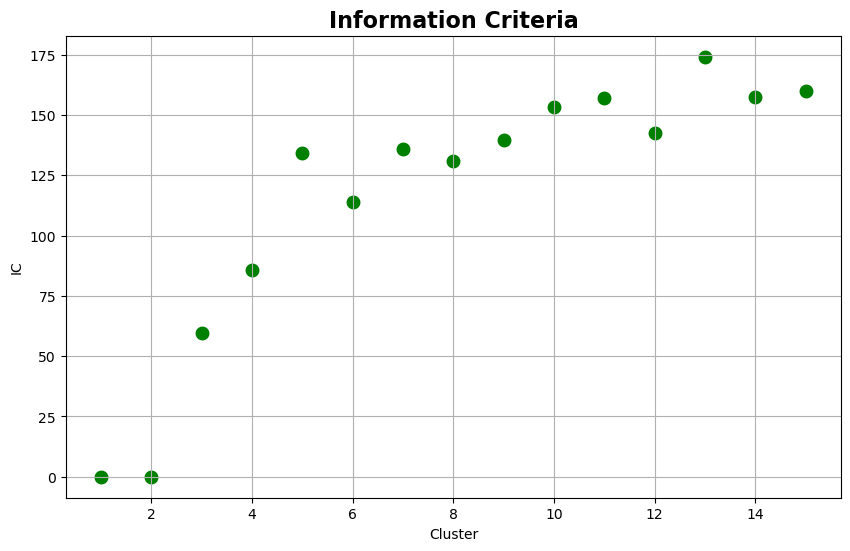

In [64]:

## As we do different iterations we can see how robust is the information criterio
# including each cluster by calculating the standard deviation
fig,ax = plt.subplots(1,1,figsize=(10,6))
ax.set_title('Information Criteria',fontsize=16,weight='bold')
ax.set_xlabel('Cluster')
ax.set_ylabel('IC')
ax.scatter(range(1,wtmax+1),np.nanstd(np.array(IC),0),linewidth= 4,color='green')
ax.grid()




### Una vez analizada la figura anterior, que es crucial, 
### decidimos el número de cluster a considerar


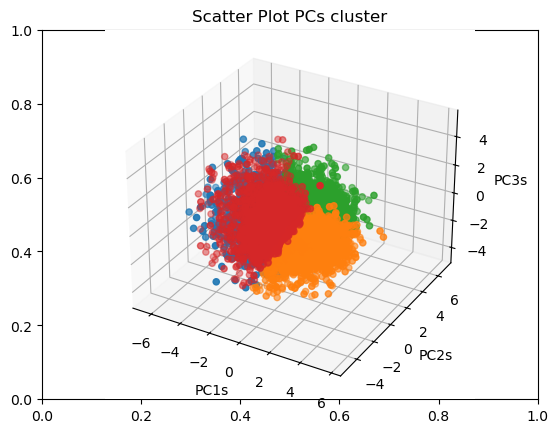

In [196]:
k=4
# For example, we decide that 5...
centroides, index = cluster.vq.kmeans2((PCs ),k)

#ahora representamos las PCs con los centroides
fig,ax = plt.subplots()
ax = plt.subplot(1,1,1, projection='3d')
ax.set_xlabel('PC1s')
ax.set_ylabel('PC2s')
ax.set_zlabel('PC3s')
ax.grid()
ax.set_title('Scatter Plot PCs cluster')

for nk in range(k):  
    ax.scatter3D(PCs[index==nk,0],PCs [index==nk,1],PCs [index==nk,2])
    
    

In [197]:
len(index)/dy

85.0

In [200]:
index

array([1, 1, 1, ..., 2, 2, 2], dtype=int32)

## Cálculo de los mapas, como multiplicación de los centroides (coordenadas de PC1, PC2 y PC3) por los EOF (como mapa de regresión Reg)
#ES COMO UNA RECONSTRUCCIÓN
cluster=centroids*Reg
CENTROIDS 4, 10
REG     10, ns

In [201]:
clusters=np.dot(centroides,REG)
clusters.shape

(4, 3600)


# =============================================================================
# DIBUJAR CLUSTER i-ésimo (en realidad son las EOFs as reg)
# =============================================================================

## también podemos calcular el valor medio del índice para cada cluster 

### 1. Probabilidad de mi indice por encima de un percentil  en cada CLUSTER

In [ ]:
#index contiene todos los años desde 1940-2023 pero solo necesito 1971-2015
indiceExtremo=preciMAMday
p95 = np.percentile(indiceExtremo, 95)

yearslp=np.arange(1940,2025)
iyslp=(yearslp >1970) & (yearslp <2016) #los años que solapan con Extremo
index2=index.reshape(85,92)
index_PeriodExt=index2[iyslp,:].reshape([45*92])
index_PeriodExt.shape
pWR=np.empty([4,1])
for i in range(4):
    pWR[i]=indiceExtremo[(index_PeriodExt==i) & (indiceExtremo>= p95)].size/(indiceExtremo[index_PeriodExt==i].size)
        

In [233]:
pWR, p95

(array([[0.02526316],
        [0.06598513],
        [0.06102522],
        [0.04180791]]),
 68.76478691101072)

pWR

### 2.  Total de mi indice para cada cluster


In [222]:
#here we calculate the total rainfall per day
TRWR1=indiceExtremo[index_PeriodExt==0].sum()/(indiceExtremo[index_PeriodExt==0].size)
TRWR2=indiceExtremo[index_PeriodExt==1].sum()/(indiceExtremo[index_PeriodExt==1].size)
TRWR3=indiceExtremo[index_PeriodExt==2].sum()/(indiceExtremo[index_PeriodExt==2].size)
TRWR4=indiceExtremo[index_PeriodExt==3].sum()/(indiceExtremo[index_PeriodExt==3].size)


###  3. frecuencia de que aparezca mi indice en cada  WR

In [223]:
FRWR1=indiceExtremo[index_PeriodExt==0].size/indiceExtremo.size*100
FRWR2=indiceExtremo[index_PeriodExt==1].size/indiceExtremo.size*100
FRWR3=indiceExtremo[index_PeriodExt==2].size/indiceExtremo.size*100
FRWR4=indiceExtremo[index_PeriodExt==3].size/indiceExtremo.size*100


# ahora los dibujamos

/home/irene/miniconda3/envs/cao_tropa3/lib/python3.9/site-packages/cartopy/mpl/gridliner.py:487: UserWarning: The .ylabels_right attribute is deprecated. Please use .right_labels to toggle visibility instead.
  warnings.warn('The .ylabels_right attribute is deprecated. Please '
/home/irene/miniconda3/envs/cao_tropa3/lib/python3.9/site-packages/cartopy/mpl/gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '


Text(0.5, 1.0, 'SLP Cluster 1 total rain=   11.03mm/day frequency   22.95%')

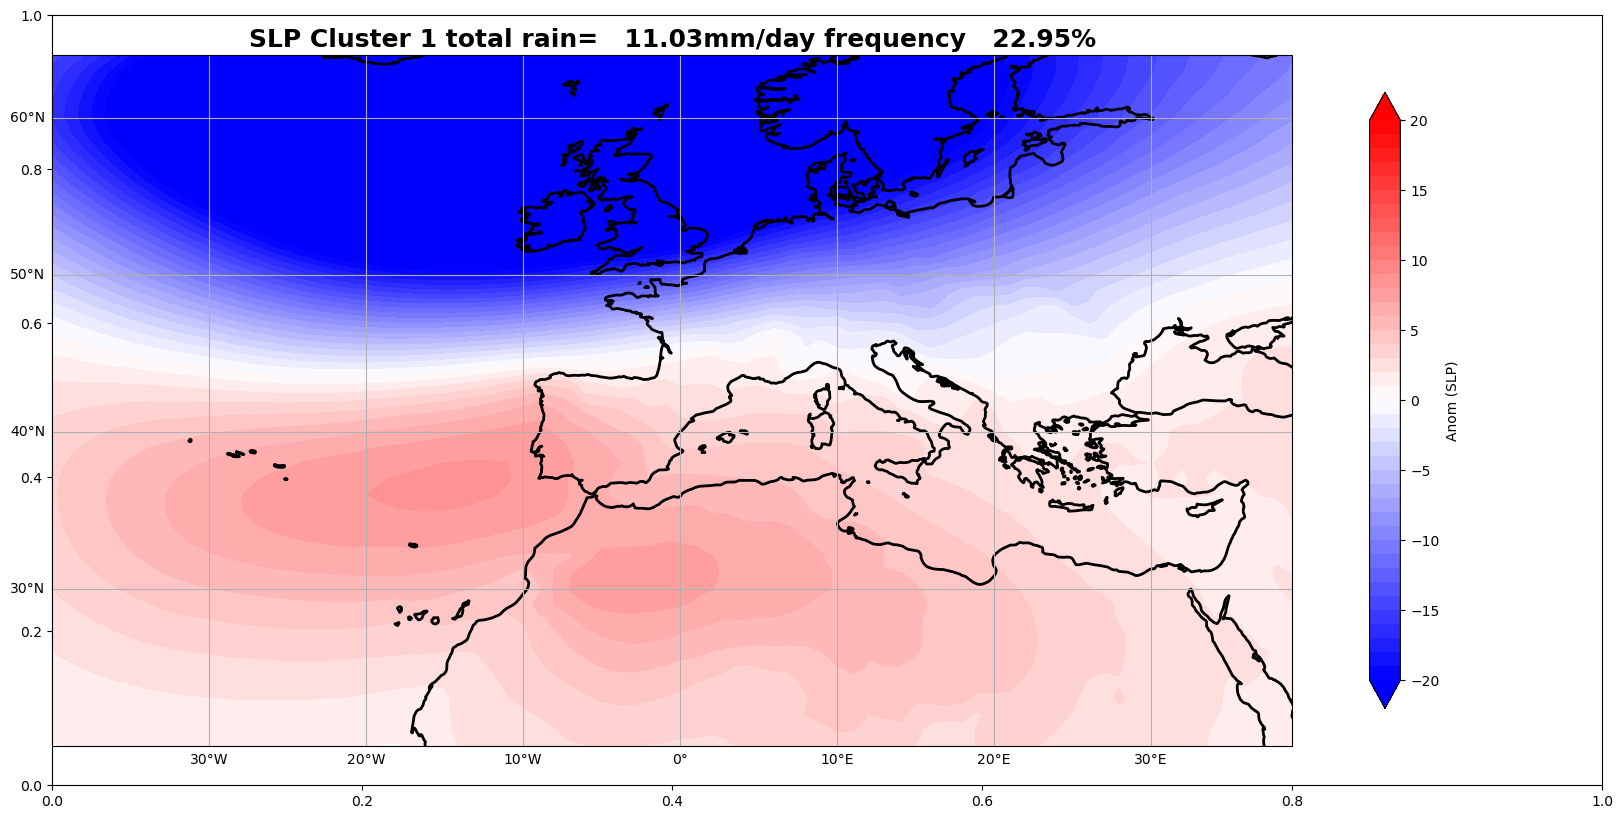

In [226]:
fig, ax = plt.subplots(figsize=(20, 10), ncols=1)
ax=plt.subplot(1,1,1,projection=ccrs.PlateCarree(0))
ax.coastlines(linewidth = 2)
im = ax.contourf(z.lon,z.lat,clusters[0,:].reshape(nlat,nlon)/100,
                 cmap='bwr',extend='both', levels=np.arange(-20,20.1,1), transform = ccrs.PlateCarree(0))#,levels=levels_cl2)

ax.coastlines()
fig.colorbar(im,ax=ax,orientation = 'vertical',shrink=0.8, label = 'Anom (SLP)')
gl=ax.gridlines(draw_labels = True); #grid
gl.ylabels_right = False #label y axis in rigth size
gl.xlabels_top = False #label x axis in top
ax.set_title('SLP Cluster 1 total rain= '+ str(f'{TRWR1:7.2f}')+'mm/day '+'frequency '+str(f'{FRWR1:7.2f}')+'%',fontsize=18,weight='bold')

/home/irene/miniconda3/envs/cao_tropa3/lib/python3.9/site-packages/cartopy/mpl/gridliner.py:487: UserWarning: The .ylabels_right attribute is deprecated. Please use .right_labels to toggle visibility instead.
  warnings.warn('The .ylabels_right attribute is deprecated. Please '
/home/irene/miniconda3/envs/cao_tropa3/lib/python3.9/site-packages/cartopy/mpl/gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '


Text(0.5, 1.0, 'SLP Cluster 2 total rain=   18.52mm/day frequency   25.99%')

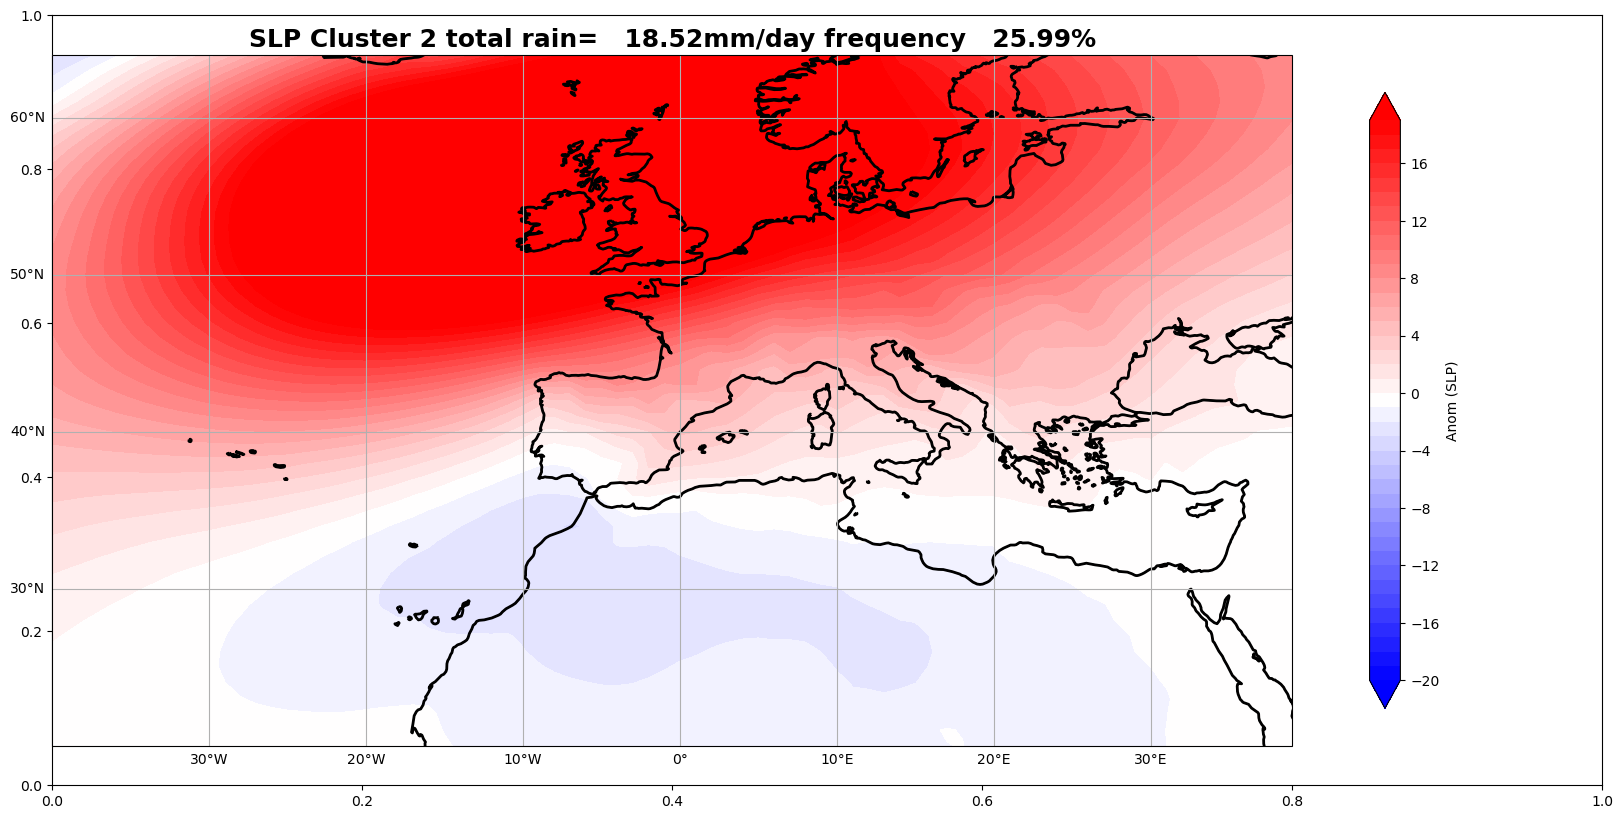

In [225]:
fig, ax = plt.subplots(figsize=(20, 10), ncols=1)
ax=plt.subplot(1,1,1,projection=ccrs.PlateCarree(0))
ax.coastlines(linewidth = 2)
im = ax.contourf(z.lon,z.lat,clusters[1,:].reshape(nlat,nlon)/100,
                 cmap='bwr',extend='both', levels=np.arange(-20,20), transform = ccrs.PlateCarree(0))#,levels=levels_cl2)

ax.coastlines()
fig.colorbar(im,ax=ax,orientation = 'vertical',shrink=0.8, label = 'Anom (SLP)')
gl=ax.gridlines(draw_labels = True); #grid
gl.ylabels_right = False #label y axis in rigth size
gl.xlabels_top = False #label x axis in top
ax.set_title('SLP Cluster 2 total rain= '+ str(f'{TRWR2:7.2f}')+'mm/day '+'frequency '+str(f'{FRWR2:7.2f}')+'%',fontsize=18,weight='bold')

/home/irene/miniconda3/envs/cao_tropa3/lib/python3.9/site-packages/cartopy/mpl/gridliner.py:487: UserWarning: The .ylabels_right attribute is deprecated. Please use .right_labels to toggle visibility instead.
  warnings.warn('The .ylabels_right attribute is deprecated. Please '
/home/irene/miniconda3/envs/cao_tropa3/lib/python3.9/site-packages/cartopy/mpl/gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '


Text(0.5, 1.0, 'SLP Cluster 3 total rain=   19.76mm/day frequency   29.69%')

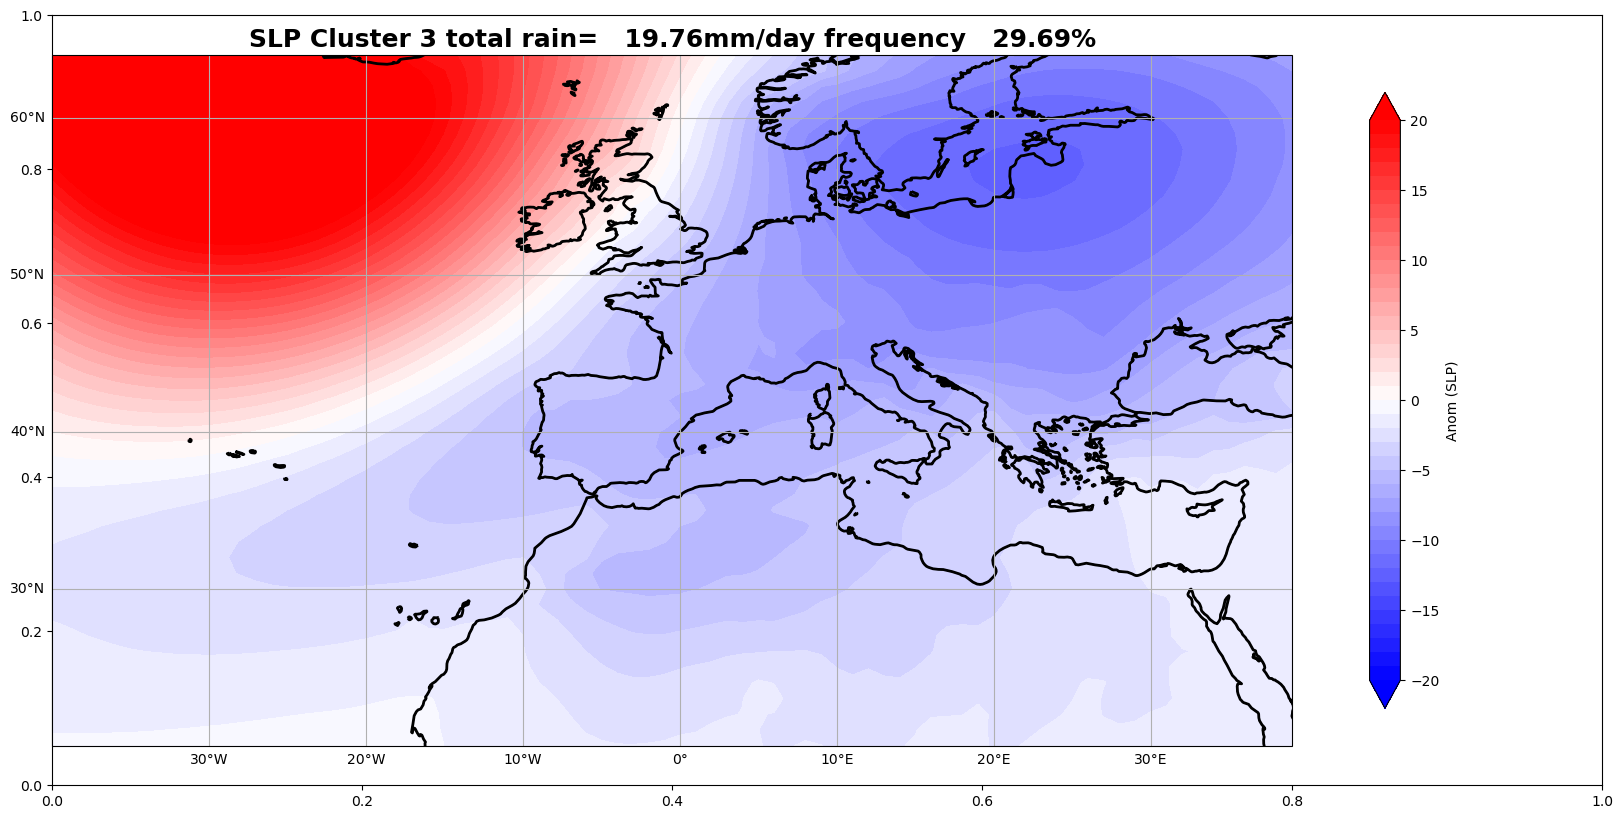

In [227]:
fig, ax = plt.subplots(figsize=(20, 10), ncols=1)
ax=plt.subplot(1,1,1,projection=ccrs.PlateCarree(0))
ax.coastlines(linewidth = 2)
im = ax.contourf(z.lon,z.lat,clusters[2,:].reshape(nlat,nlon)/100,
                 cmap='bwr',extend='both', levels=np.arange(-20,20.1,1), transform = ccrs.PlateCarree(0))#,levels=levels_cl2)

ax.coastlines()
fig.colorbar(im,ax=ax,orientation = 'vertical',shrink=0.8, label = 'Anom (SLP)')
gl=ax.gridlines(draw_labels = True); #grid
gl.ylabels_right = False #label y axis in rigth size
gl.xlabels_top = False #label x axis in top
ax.set_title('SLP Cluster 3 total rain= '+ str(f'{TRWR3:7.2f}')+'mm/day '+'frequency '+str(f'{FRWR3:7.2f}')+'%',fontsize=18,weight='bold')

/home/irene/miniconda3/envs/cao_tropa3/lib/python3.9/site-packages/cartopy/mpl/gridliner.py:487: UserWarning: The .ylabels_right attribute is deprecated. Please use .right_labels to toggle visibility instead.
  warnings.warn('The .ylabels_right attribute is deprecated. Please '
/home/irene/miniconda3/envs/cao_tropa3/lib/python3.9/site-packages/cartopy/mpl/gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '


Text(0.5, 1.0, 'SLP Cluster 4 total rain=   14.49mm/day frequency   21.38%')

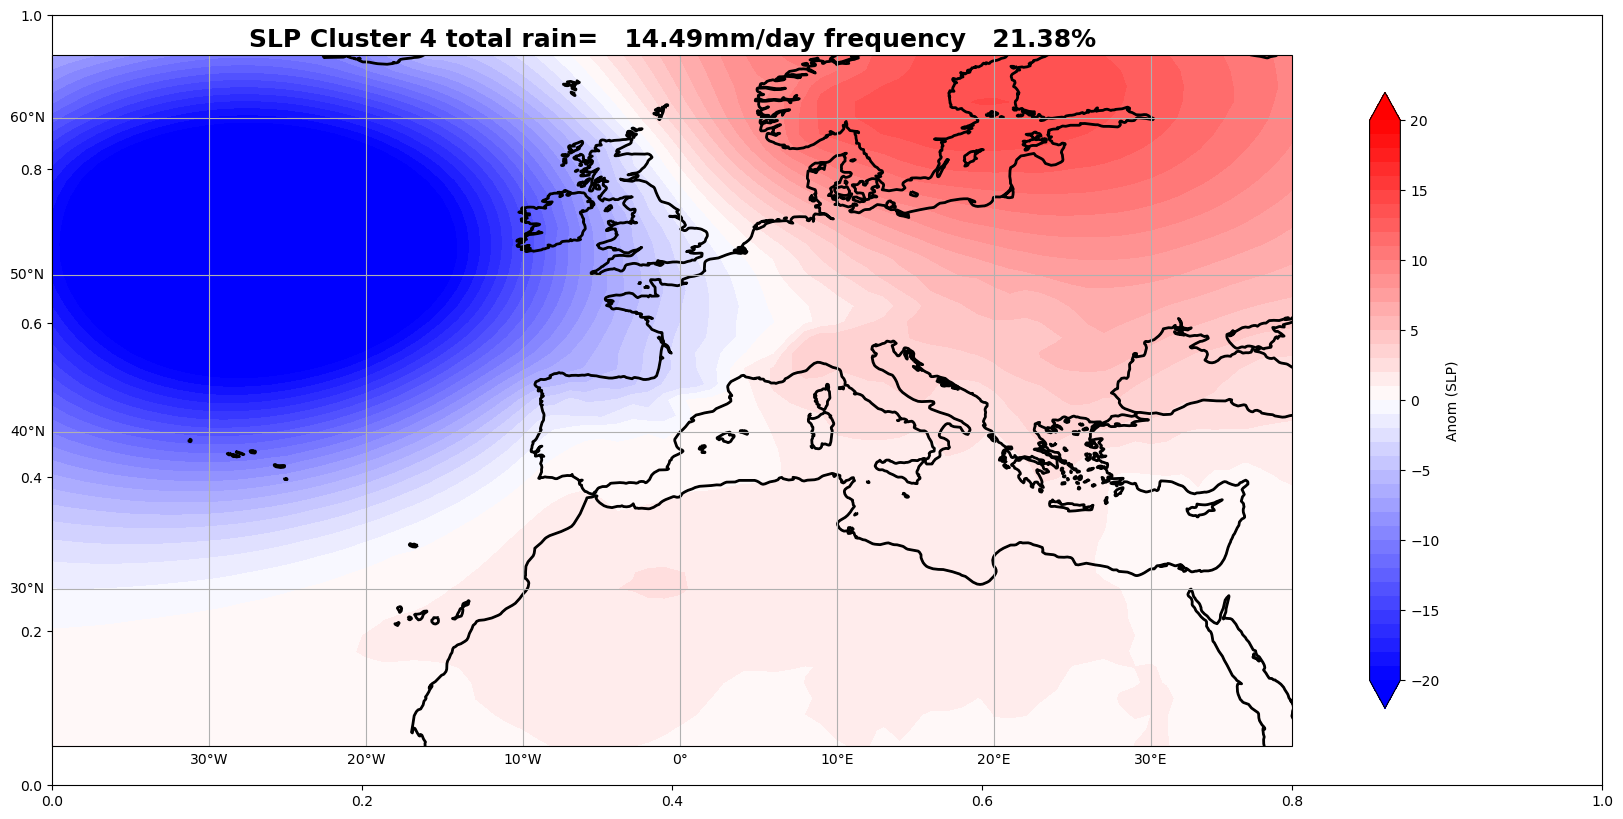

In [228]:
fig, ax = plt.subplots(figsize=(20, 10), ncols=1)
ax=plt.subplot(1,1,1,projection=ccrs.PlateCarree(0))
ax.coastlines(linewidth = 2)
im = ax.contourf(z.lon,z.lat,clusters[3,:].reshape(nlat,nlon)/100,
                 cmap='bwr',extend='both', levels=np.arange(-20,20.1,1), transform = ccrs.PlateCarree(0))#,levels=levels_cl2)

ax.coastlines()
fig.colorbar(im,ax=ax,orientation = 'vertical',shrink=0.8, label = 'Anom (SLP)')
gl=ax.gridlines(draw_labels = True); #grid
gl.ylabels_right = False #label y axis in rigth size
gl.xlabels_top = False #label x axis in top
ax.set_title('SLP Cluster 4 total rain= '+ str(f'{TRWR4:7.2f}')+'mm/day '+'frequency '+str(f'{FRWR4:7.2f}')+'%',fontsize=18,weight='bold')



In [229]:
#de la misma forma podemos crear los cluster a partir de index, haciendo un compuesto de los días que caén en ese cluster
COMP=np.zeros([4,ns])
FREQI=np.zeros(4) #FRECUENCIA DEL INDICE EN SI
for i in range(4):
    nindex=np.sum(index==i) #numero de dias que están en el cluster i
    Maskind=index==i #mascara de los días que están en el cluster i
    COMP[i,:]=np.sum(Mata[Maskind,:],axis=0)/nindex
    FREQI[i]=100*nindex/len(index)

/home/irene/miniconda3/envs/cao_tropa3/lib/python3.9/site-packages/cartopy/mpl/gridliner.py:487: UserWarning: The .ylabels_right attribute is deprecated. Please use .right_labels to toggle visibility instead.
  warnings.warn('The .ylabels_right attribute is deprecated. Please '
/home/irene/miniconda3/envs/cao_tropa3/lib/python3.9/site-packages/cartopy/mpl/gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '


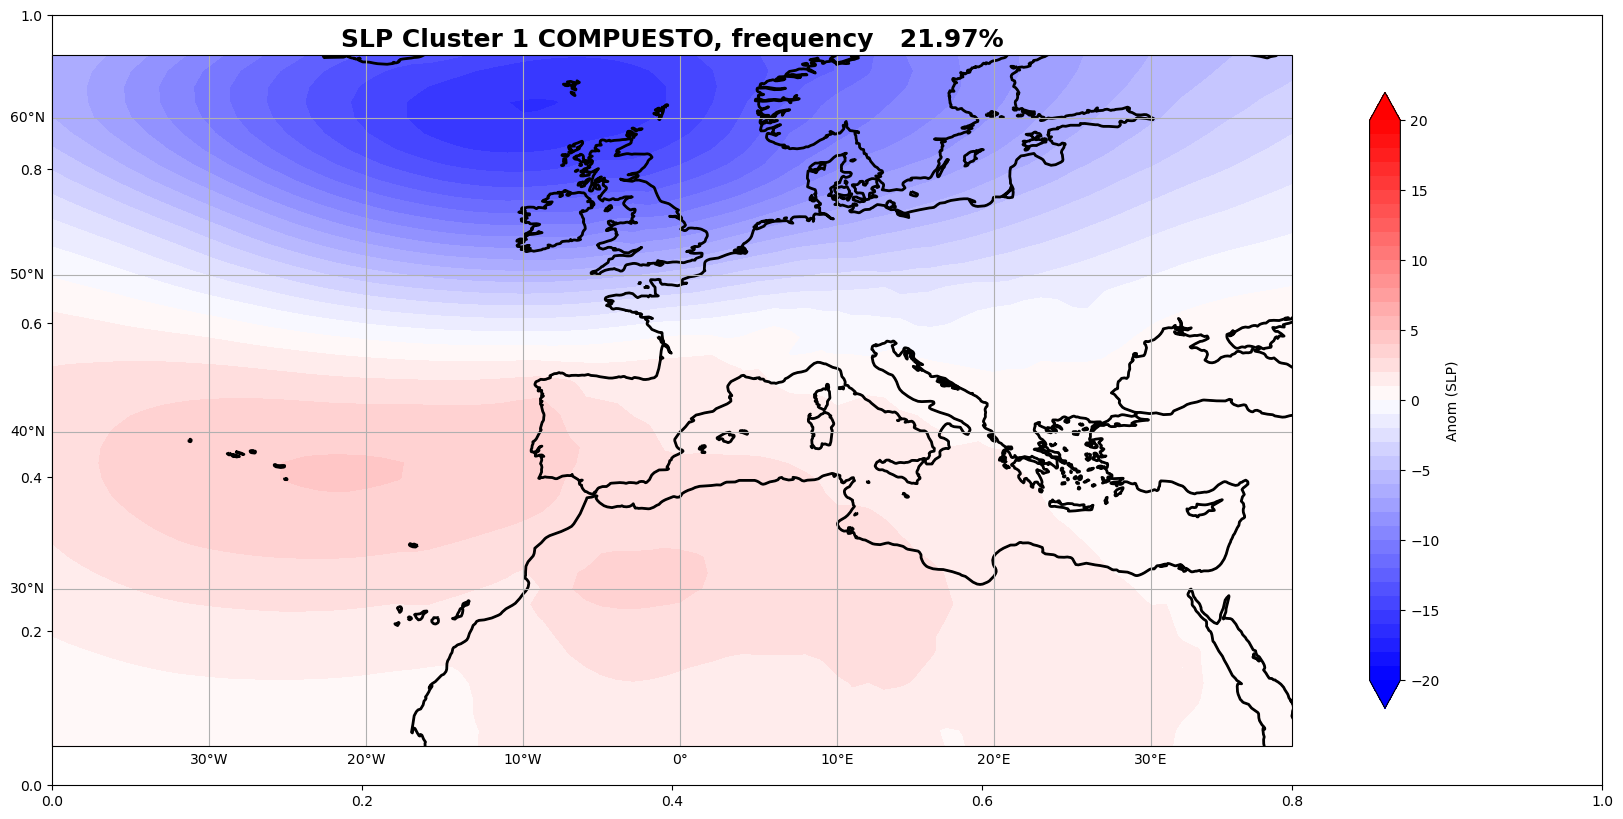

In [ ]:
#Pruebo a pintar el compuesto
fig, ax = plt.subplots(figsize=(20, 10), ncols=1)
ax=plt.subplot(1,1,1,projection=ccrs.PlateCarree(0))
ax.coastlines(linewidth = 2)
im = ax.contourf(z.lon,z.lat,COMP[0,:].reshape(nlat,nlon)/100,
                 cmap='bwr',extend='both', levels=np.arange(-20,20.1,1), transform = ccrs.PlateCarree(0))#,levels=levels_cl2)

ax.coastlines()
fig.colorbar(im,ax=ax,orientation = 'vertical',shrink=0.8, label = 'Anom (SLP)')
ax.set_title('SLP Cluster 4 COMPUESTO, frequency '+str(f'{FREQI[0]:7.2f}')+'%',fontsize=18,weight='bold')
gl=ax.gridlines(draw_labels = True); #grid
gl.ylabels_right = False #label y axis in rigth size
gl.xlabels_top = False #label x axis in top

# Interanual variability

In [231]:
## ahora, para cada año, vas viendo la frecuencia de tu cluster
nyr=84
wr1= ma.empty([nyr,])
wr2= ma.empty([nyr,])
wr3= ma.empty([nyr,])
wr4= ma.empty([nyr,])


k=0

# each year contains  ndy days
for i in range(nyr):
    wr1[i] = sum(index[k:k+dy] == 0) #sumo todos los valores del índice
    wr2[i] = sum(index[k:k+dy] == 1) 
    wr3[i] = sum(index[k:k+dy] == 2)
    wr4[i] = sum(index[k:k+dy] == 3)
   
    k=k+dy



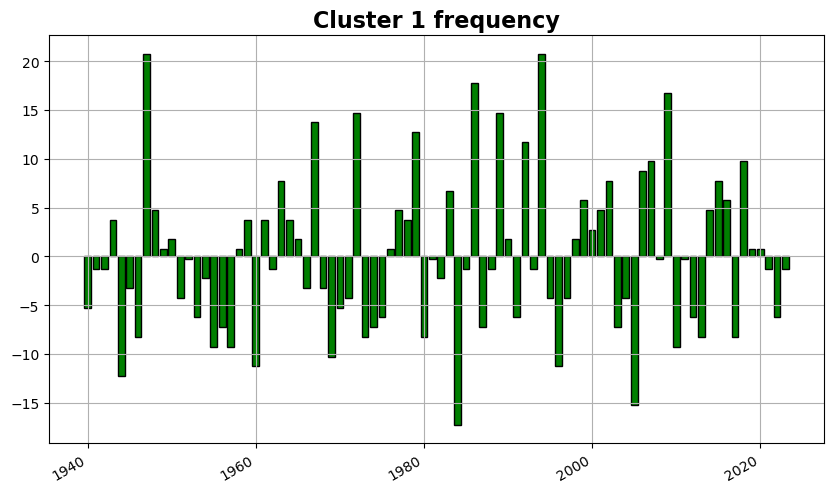

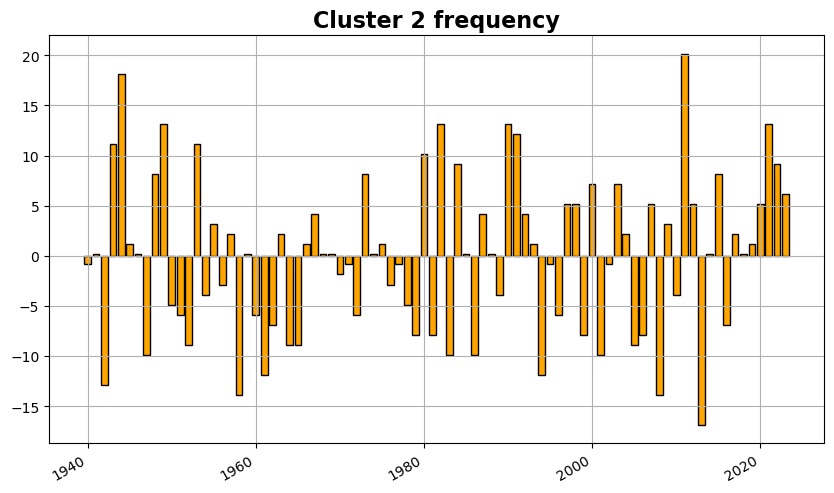

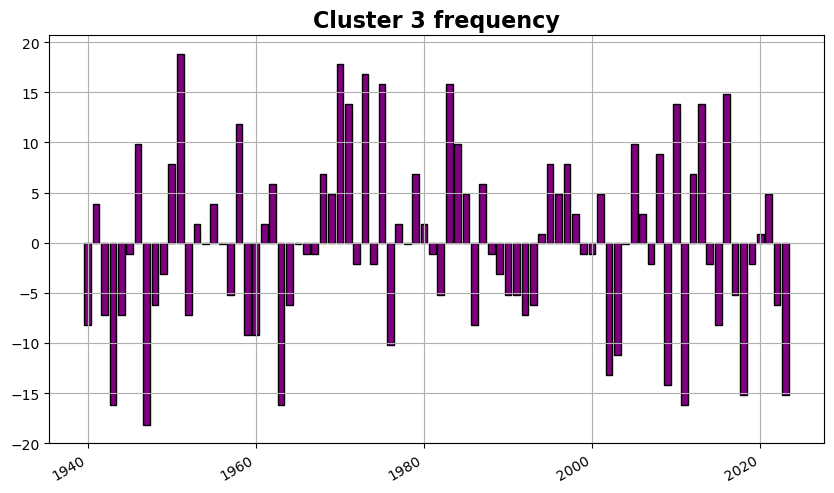

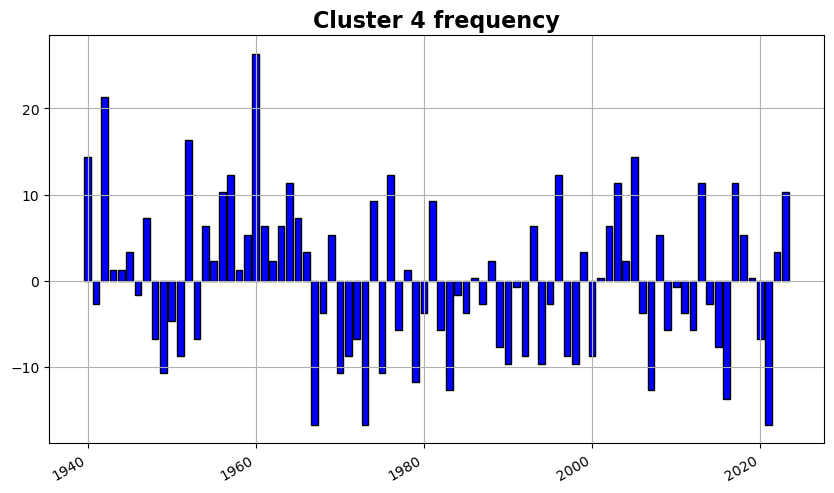

In [232]:

# Ploteamos las frecuencias
fig,ax = plt.subplots(1,1,figsize=(10,6))
fig.autofmt_xdate(rotation=30) 
ax.set_title('Cluster 1 frequency',fontsize=16,weight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
#ax.xaxis.set_major_formatter(mdates.DateFormatter('%y'))
ax.bar(np.arange(1940,2024),wr1-wr1.mean(),linewidth= 1,color='green', edgecolor = 'k')
ax.grid()

fig,ax = plt.subplots(1,1,figsize=(10,6))
fig.autofmt_xdate(rotation=30) 
ax.set_title('Cluster 2 frequency',fontsize=16,weight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
#ax.xaxis.set_major_formatter(mdates.DateFormatter('%y'))
ax.bar(np.arange(1940,2024),wr2-wr2.mean(),linewidth= 1,color='orange', edgecolor = 'k')
ax.grid()

fig,ax = plt.subplots(1,1,figsize=(10,6))
fig.autofmt_xdate(rotation=30) 
ax.set_title('Cluster 3 frequency',fontsize=16,weight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
#ax.xaxis.set_major_formatter(mdates.DateFormatter('%y'))
ax.bar(np.arange(1940,2024),wr3-wr3.mean(),linewidth= 1,color='purple', edgecolor = 'k')
ax.grid()

fig,ax = plt.subplots(1,1,figsize=(10,6))
fig.autofmt_xdate(rotation=30) 
ax.set_title('Cluster 4 frequency',fontsize=16,weight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
#ax.xaxis.set_major_formatter(mdates.DateFormatter('%y'))
ax.bar(np.arange(1940,2024),wr4-wr4.mean(),linewidth= 1,color='blue', edgecolor = 'k')
ax.grid()